# Brand value and the sponsorship's incremental brand value

**Review notebook** for `brand_value_dominance_v1` (brand value from the brand's share of Lenovo-specific price formation, and the FIFA-specific incremental value; ADR-0031, ADR-0032, ADR-0040, ADR-0043, ADR-0044), with the comparison routes `sponsorship_total_return_v3` and `valuation_routes_v1` (ADR-0030). It follows the human-review standard in `AGENTS.md`. The economic-profit DCF (ADR-0033) was retired by ADR-0040.

> **Status: planning valuation, not accepted.** The brand's share is read from share-price relative importance and is not statistically identified by the market data alone (section 5.3); the level is corroborated by independent valuations (section 5.4). Quote any figure with its range and these caveats.

*How to use:* run all cells. Read-only unless `RUN_REBUILD = True`. Narrative numbers are computed from current outputs.

In [1]:
# Setup: read-only by default (AGENTS.md). Nothing below rewrites data unless RUN_REBUILD is True.
RUN_REBUILD = False   # set True only to regenerate the production outputs this notebook reads

import json, os, subprocess, sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "srmp").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from srmp.review import stamp_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

def md(text):
    display(Markdown(text))

def fmt(value, digits=2, signed=False):
    return f"{value:+.{digits}f}" if signed else f"{value:.{digits}f}"

if RUN_REBUILD:  # explicit opt-in: re-runs the valuation experiments (a few minutes: placebo draws)
    for module in ["srmp.experiments.stock_brand_response_v2", "srmp.experiments.sponsorship_total_return_v3",
                   "srmp.experiments.valuation_routes_v1", "srmp.experiments.brand_value_dominance_v1"]:
        subprocess.run([sys.executable, "-m", module], check=True)

E = "data/curated/experimental/"
D = E + "brand_value_dominance_v1/"
SOURCES = [
    "config/experiments/brand_value_dominance_v1.yaml", "data/curated/index/brand_index_manifest.json",
    E + "stock_brand_response_v2/stock_response_manifest.json",
    D + "brand_value_dominance_manifest.json", D + "dominance_weights.parquet", D + "stability.parquet",
    E + "sponsorship_total_return_v3/total_return_v3_manifest.json",
    E + "valuation_routes_v1/valuation_routes.parquet", E + "valuation_routes_v1/breakeven.parquet",
    E + "sponsorship_total_effect_v1/estimate_manifest.json", E + "sponsorship_total_effect_v1/donor_sensitivity.parquet",
    E + "sponsorship_exposure_timing_v1/exposure_timing_manifest.json",
]
stamp_sources(SOURCES)
dom = json.loads(Path(D + "brand_value_dominance_manifest.json").read_text())
values, chain, fs, P, ref = dom["values"], dom["primary_result"], dom["fifa_specific_incremental_brand_value"], dom["placebo"], dom["external_reference"]
effect = json.loads(Path(E + "sponsorship_total_effect_v1/estimate_manifest.json").read_text())

REVIEW_SOURCES={"config/experiments/brand_value_dominance_v1.yaml": "ca3e30680fb263d5be13cd941ce5f0e3ea999512a060ab1bceaad81bb93c86af", "data/curated/index/brand_index_manifest.json": "18db10277b376a95c97748dafcc8c1b384cbf991bab061cf190af77e0bb0051e", "data/curated/experimental/stock_brand_response_v2/stock_response_manifest.json": "292662068ea28ec8936c019ae1ac9581f8a4b49e9df1b80486b7db010d4de64b", "data/curated/experimental/brand_value_dominance_v1/brand_value_dominance_manifest.json": "47f55fec2415db79caaca67e1a54a44be1e56a03e7347924a88d164566d0fa9c", "data/curated/experimental/brand_value_dominance_v1/dominance_weights.parquet": "c7fcdf291c0fbc9591e328dd0c7ca5caa2e88f40cce51208f2c0595fc87420ab", "data/curated/experimental/brand_value_dominance_v1/stability.parquet": "44c304bf571135dba4f9c6201e69b09f55841dd6922e2256a78f6d78a0ed24b9", "data/curated/experimental/sponsorship_total_return_v3/total_return_v3_manifest.json": "7c02e6fdac827993171debe1e1bb2119cf6011ac9aa3412723190887b1ab328a

## 1. Question and purpose

**Questions.** (a) What is the Lenovo brand worth, read as the brand's share of what Lenovo's own drivers move in its share price? (b) Given the FIFA-specific lift in the Brand Index, how much brand value did FIFA add?

**Why it matters.** The client needs a money translation of the sponsorship's brand effect. This notebook makes every step explicit, including the points where the evidence is thin.

**Objective supported.** Monetisation of the sponsorship's brand uplift (downstream of, and conditional on, the uplift analysis).

## 2. Evidence and inputs

| Input | Value / source | Label |
|---|---|---|
| Lenovo weekly log returns, Hang Seng and lagged Nasdaq-100 (HKD) returns | Yahoo Finance daily prices | **observed** |
| Brand-index innovation | Unexpected weekly change in the Brand Index, predicted from prior data only (`stock_brand_response_v2`) | **estimated** |
| Category demand, Lenovo events (earnings, launches, promotions) | Google Trends rival searches; Lenovo press and results calendars | **observed** / **constructed** |
| Market capitalisation | Mean over the post-announcement weeks (primary), latest and pre-announcement (sensitivities) | **observed** |
| FIFA-specific uplift | Part of the synthetic-control gap explained by accumulated FIFA exposure (ADR-0043) | **estimated** |
| Brand value elasticity to brand share = 1 | Proportionality | **assumed** |
| Brand Finance 2025; Interbrand 2015 | Published brand valuations (royalty relief; Best Global Brands) | **borrowed** (corroboration only, never an input) |

## 3. Method and formulas

**Brand share of Lenovo-specific price formation (ADR-0044).** Weekly Lenovo log returns $r_t$ are regressed on four groups of drivers $G$: market factors, PC category demand, Lenovo events, and the Brand Index innovation. General dominance gives each group its average incremental $R^2$ over all orderings of the other groups (Shapley–Owen):

$$D_g = \frac{1}{|G|}\sum_{k=0}^{|G|-1} \overline{\Big[R^2(S \cup \{g\}) - R^2(S)\Big]}_{|S|=k,\ g \notin S}, \qquad \sum_g D_g = R^2_{full}.$$

The brand's share is taken among the Lenovo-specific groups only, signed by its full-model coefficient:

$$s = \operatorname{sign}(\hat\beta_{brand}) \cdot \frac{D_{brand}}{\sum_{g \ne market} D_g}, \qquad BV = s \cdot \text{MarketCap}.$$

*In words:* market-wide moves reflect interest rates and risk appetite, not Lenovo's earning power, so they are set aside; of the movement Lenovo's own drivers explain, the brand's share is read as its share of the company's value (ADR-0031 reading of price formation, restricted to Lenovo-specific drivers by ADR-0044). The share of *all* explained movement, market included, is kept in the manifest as a secondary reference (`values.literal_reading_reference`).

**From the FIFA-specific lift to incremental brand value.** The Brand Index is proportional to Lenovo's brand share of attention (ADR-0040), so a lift $\Delta$ over the no-sponsorship level $I_{cf}$ is an uplift $u = \Delta / I_{cf}$, and

$$\Delta BV = \varepsilon \cdot u \cdot BV, \qquad \varepsilon = 1 .$$

*In words:* FIFA's percentage uplift in brand share is applied one-for-one to brand value.

**Placebo test of the share.** The brand column is replaced by (i) 500 random series and (ii) the real brand series shifted out of step with returns by every lag from 8 weeks; each time the share an unrelated regressor obtains is recorded. *In words:* how large a share would something meaningless get?

## 4. Calculation path

| Step | Code | Configuration | Output |
|---|---|---|---|
| Brand Index | `srmp/index/brand_factor.py` | `config/brand_index.yaml` | `data/curated/index/brand_index_weekly.parquet` |
| Stock-return drivers, brand innovation | `srmp/experiments/stock_brand_response_v2.py` | `config/experiments/stock_brand_response_v2.yaml` | `stock_brand_response_v2/` |
| FIFA-specific uplift | `srmp/experiments/sponsorship_exposure_timing_v1.py` | `config/experiments/sponsorship_exposure_timing_v1.yaml` | `sponsorship_exposure_timing_v1/` |
| Dominance shares, brand value, placebo, incremental value | `srmp/experiments/brand_value_dominance_v1.py` (`group_dominance`, `_lenovo_specific`, `_placebos`) | `config/experiments/brand_value_dominance_v1.yaml` | `brand_value_dominance_v1/` |
| Comparison routes | `srmp/experiments/valuation_routes_v1.py`, `sponsorship_total_return_v3.py` | `config/experiments/` | `valuation_routes_v1/`, `sponsorship_total_return_v3/` |

## 5. Results

### 5.1 What drives Lenovo's own share-price movement

In [2]:
wts = pd.read_parquet(D + "dominance_weights.parquet")
display(wts[["group", "dominance_r2", "share_of_explained", "share_of_lenovo_specific"]].rename(columns={
    "group": "Driver group", "dominance_r2": "Dominance (R² points)", "share_of_explained": "Share of all explained movement",
    "share_of_lenovo_specific": "Share of Lenovo-specific explained movement"})
    .style.format({"Dominance (R² points)": "{:.4f}", "Share of all explained movement": "{:.1%}", "Share of Lenovo-specific explained movement": "{:.1%}"}, na_rep="— (set aside)").hide(axis="index"))
coef = dom["coefficients"]["brand_full_sample"]["brand"]
rest = wts.loc[wts["group"] != "market", "dominance_r2"].sum()
md(f"**Table 1.** {dom['samples']['brand_weeks']} weeks; full-model R² = {dom['samples']['brand_model_r2']:.3f}, of which Lenovo-specific drivers {rest:.4f}. "
   f"Brand share of the Lenovo-specific explained movement: **{values['brand_share']:.1%}** (coefficient {coef['coefficient']:+.5f}, robust s.e. {coef['robust_se']:.5f}, t = {coef['coefficient']/coef['robust_se']:+.2f}).")

Driver group,Dominance (R² points),Share of all explained movement,Share of Lenovo-specific explained movement
market,0.1640,91.2%,— (set aside)
category_demand,0.0042,2.3%,26.4%
lenovo_events,0.0079,4.4%,49.8%
brand,0.0038,2.1%,23.8%


**Table 1.** 164 weeks; full-model R² = 0.180, of which Lenovo-specific drivers 0.0159. Brand share of the Lenovo-specific explained movement: **23.8%** (coefficient +0.00298, robust s.e. 0.00255, t = +1.17).

### 5.2 Brand value

In [3]:
display(pd.DataFrame([
    ("Brand share of Lenovo-specific drivers", f"{values['brand_share']:.1%}"),
    ("90% block-bootstrap range of the share", f"{values['brand_share_90pct'][0]:.0%} to {values['brand_share_90pct'][1]:.0%}"),
    (f"Market capitalisation ({values['market_cap_base'].replace('_', ' ')})", f"US${values['market_cap_usd_m']/1000:.1f}bn"),
    ("**Lenovo brand value**", f"**US${values['brand_value_usd_m']/1000:.2f}bn**"),
    ("90% range of brand value", f"US${values['brand_value_90pct_usd_m'][0]/1000:.1f}bn to US${values['brand_value_90pct_usd_m'][1]/1000:.1f}bn"),
    ("Value per Brand Index point", f"US${chain['coefficient_usd_m_per_index_point']:.1f}m"),
], columns=["Item", "Value"]).style.hide(axis="index"))
caps = pd.Series(values["brand_value_by_cap_base_usd_m"]).rename("Brand value (US$m)").to_frame()
display(caps.style.format("{:,.0f}"))
lit = values["literal_reading_reference"]
md(f"**Tables 2–3.** Secondary reference (ADR-0031 literal reading, not used): the brand's share of *all* explained movement, market included, is {lit['brand_share']:.2%} (US${lit['brand_value_usd_m']:,.0f}m).")

Item,Value
Brand share of Lenovo-specific drivers,23.8%
90% block-bootstrap range of the share,-10% to 69%
Market capitalisation (mean post announcement market cap),US$21.2bn
**Lenovo brand value**,**US$5.04bn**
90% range of brand value,US$-2.1bn to US$14.5bn
Value per Brand Index point,US$49.4m


,Brand value (US$m)
pre_announcement_market_cap,"4,143"
latest_market_cap,"13,490"
mean_post_announcement_market_cap,"5,039"


**Tables 2–3.** Secondary reference (ADR-0031 literal reading, not used): the brand's share of *all* explained movement, market included, is 2.10% (US$446m).

### 5.3 How firm is the share? Stability and placebo

Check,Weeks,Model R²,Brand share (Lenovo-specific),Brand value (US$m),FIFA-added value (US$m)
sample 2022-01-01 to 2024-10-14,62,0.363,3.3%,691,30
sample 2024-10-15 to 2026-12-31,102,0.167,20.4%,"4,326",187
sample 2022-01-01 to 2025-12-31,125,0.360,25.9%,"5,483",238
without category_demand,164,0.176,28.0%,"5,939",257
without lenovo_events,164,0.167,41.5%,"8,808",382
with earnings_weeks as an extra Lenovo-specific group,164,0.180,26.8%,"5,686",246
with momentum as an extra Lenovo-specific group,164,0.180,23.6%,"5,000",217
brand measured as delta_brand_index,164,0.178,22.3%,"4,720",204


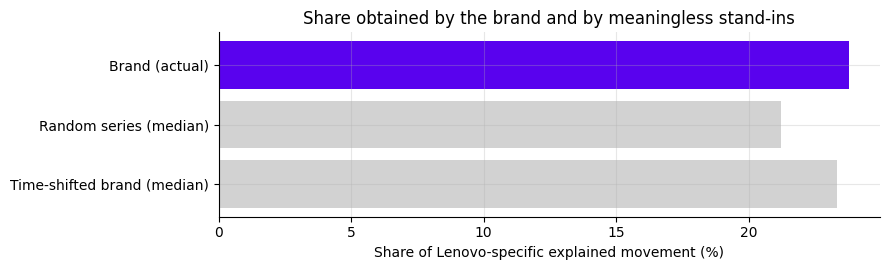

**Table 4 and Figure 1.** Across samples and control sets the share ranges 3%–42% (lowest in the pre-announcement weeks alone). A random series obtains a median 21% and reaches the brand's share with probability **0.47**; the time-shifted brand series 23% (probability 0.50). The Lenovo-specific drivers explain too little of weekly returns for the data to identify how that explanation divides: the brand's share is a reading, not a measurement.

In [4]:
stab = pd.read_parquet(D + "stability.parquet")
display(stab[["check", "weeks", "r2", "brand_share", "brand_value_usd_m", "incremental_brand_value_usd_m"]].rename(columns={
    "check": "Check", "weeks": "Weeks", "r2": "Model R²", "brand_share": "Brand share (Lenovo-specific)",
    "brand_value_usd_m": "Brand value (US$m)", "incremental_brand_value_usd_m": "FIFA-added value (US$m)"})
    .style.format({"Model R²": "{:.3f}", "Brand share (Lenovo-specific)": "{:.1%}", "Brand value (US$m)": "{:,.0f}", "FIFA-added value (US$m)": "{:,.0f}"}).hide(axis="index"))
fig, ax = plt.subplots(figsize=(9, 2.8))
labels = ["Brand (actual)", "Random series (median)", "Time-shifted brand (median)"]
vals = [P["actual_unsigned_share"], P["random_series"]["median"], P["time_shifted_brand"]["median"]]
ax.barh(labels, [100 * v for v in vals], color=["#5902EE", "#D2D2D2", "#D2D2D2"])
ax.set_xlabel("Share of Lenovo-specific explained movement (%)"); ax.invert_yaxis()
ax.set_title("Share obtained by the brand and by meaningless stand-ins"); plt.tight_layout(); plt.show()
md(f"**Table 4 and Figure 1.** Across samples and control sets the share ranges {dom['stability_summary']['brand_share_min']:.0%}–{dom['stability_summary']['brand_share_max']:.0%} "
   f"(lowest in the pre-announcement weeks alone). A random series obtains a median {P['random_series']['median']:.0%} and reaches the brand's share with probability "
   f"**{P['random_series']['probability_at_or_above_actual']:.2f}**; the time-shifted brand series {P['time_shifted_brand']['median']:.0%} (probability {P['time_shifted_brand']['probability_at_or_above_actual']:.2f}). "
   "The Lenovo-specific drivers explain too little of weekly returns for the data to identify how that explanation divides: the brand's share is a reading, not a measurement.")

### 5.4 Corroboration by independent valuations

In [5]:
ext = pd.DataFrame([
    ("This study (2026, share-price relative importance)", values["brand_value_usd_m"]),
    ("Brand Finance China 500 2025 (royalty relief)", ref["brand_finance_2025_brand_value_usd_m"]),
    ("Interbrand Best Global Brands 2015 (as reported by Lenovo)", ref["interbrand_2015_brand_value_usd_m"]),
], columns=["Valuation", "Brand value (US$m)"])
display(ext.style.format({"Brand value (US$m)": "{:,.0f}"}).hide(axis="index"))
md(f"**Table 5.** Three different methods, about a decade apart, land between US${ext['Brand value (US$m)'].min()/1000:.1f}bn and US${ext['Brand value (US$m)'].max()/1000:.1f}bn. "
   "That convergence, not the regression alone, is what makes the level credible. Sources: "
   f"[Brand Finance]({ref['source']}), [Lenovo on Interbrand 2015]({ref['interbrand_source']}).")

Valuation,Brand value (US$m)
"This study (2026, share-price relative importance)","5,039"
Brand Finance China 500 2025 (royalty relief),"5,663"
Interbrand Best Global Brands 2015 (as reported by Lenovo),"4,100"


**Table 5.** Three different methods, about a decade apart, land between US$4.1bn and US$5.7bn. That convergence, not the regression alone, is what makes the level credible. Sources: [Brand Finance](https://static.brandirectory.com/reports/brand-finance-china-500-2025-preview.pdf), [Lenovo on Interbrand 2015](https://news.lenovo.com/?p=2553).

### 5.5 FIFA-added brand value (primary, ADR-0043)

In [6]:
u = fs["uplift_pct"]; inc = fs["incremental_brand_value_usd_m"]
display(pd.DataFrame([
    ("Primary (FIFA-specific)", u["primary"], inc["primary"]),
    ("95% band, low", u["statistical_band_95_low"], inc["statistical_band_95_low"]),
    ("95% band, high", u["statistical_band_95_high"], inc["statistical_band_95_high"]),
    ("Ceiling: whole gap, same weeks", u["attribution_band_upper"], inc["attribution_band_upper"]),
], columns=["Case", "Uplift (% brand share)", "FIFA-added brand value (US$m)"])
    .style.format({"Uplift (% brand share)": "{:+.2f}%", "FIFA-added brand value (US$m)": "{:,.0f}"}).hide(axis="index"))
b90 = fs["incremental_brand_value_brand_share_90pct_usd_m"]
md(f"**Table 6.** FIFA-specific uplift ({fs['period'][0]} to {fs['period'][1]}) × brand value US${fs['brand_value_usd_m']/1000:.2f}bn. "
   f"Holding the uplift at its primary value, the brand-share bootstrap alone spans US${b90[0]:,.0f}m to US${b90[1]:,.0f}m. "
   f"The total effect over the full post period ({chain['brand_share_uplift_pct']:+.1f}%) would give US${chain['incremental_brand_value_usd_m']:,.0f}m (upper attribution band).")

Case,Uplift (% brand share),FIFA-added brand value (US$m)
Primary (FIFA-specific),+4.33%,218
"95% band, low",+1.67%,84
"95% band, high",+7.00%,353
"Ceiling: whole gap, same weeks",+6.88%,347


**Table 6.** FIFA-specific uplift (2024-10-21 to 2026-07-20) × brand value US$5.04bn. Holding the uplift at its primary value, the brand-share bootstrap alone spans US$-91m to US$630m. The total effect over the full post period (+7.3%) would give US$370m (upper attribution band).

### 5.6 Comparison routes (market-implied, profit, royalty, event study)

In [7]:
routes = pd.read_parquet(E + "valuation_routes_v1/valuation_routes.parquet")
routes = routes[routes["route"] != "industry_claimed_media_value"]   # P1: media value is never money
display(routes[["route", "link_estimate", "link_lower_95", "link_upper_95", "link_identified", "value_unit", "value_at_measured_level"]].rename(columns={
    "route": "Route", "link_estimate": "Link estimate", "link_lower_95": "95% low", "link_upper_95": "95% high",
    "link_identified": "Link statistically identified", "value_unit": "Value unit", "value_at_measured_level": "Value at measured lift"})
    .style.format({"Link estimate": "{:.4f}", "95% low": "{:.4f}", "95% high": "{:.4f}", "Value at measured lift": "{:,.1f}"}, na_rep="—").hide(axis="index"))
be = pd.read_parquet(E + "valuation_routes_v1/breakeven.parquet")
royalty = be[be["route"].eq("relief_from_royalty")][["cost_usd_m", "required_royalty_uplift_basis_points"]]
display(royalty.rename(columns={"cost_usd_m": "Annual sponsorship cost (US$m)", "required_royalty_uplift_basis_points": "Royalty-rate uplift needed (bp)"})
        .style.format("{:.1f}").hide(axis="index"))
md(f"**Tables 7–8.** Routes with a statistically identified brand-to-money link: {', '.join(routes.loc[routes['link_identified'], 'route']) or 'none'}. These routes use the total effect, not the FIFA-specific part.")

Route,Link estimate,95% low,95% high,Link statistically identified,Value unit,Value at measured lift
market_implied_equity_v3,0.0102,-0.0059,0.0263,False,"full-contract equity value, US$m","2,078.9"
market_implied_annual_earnings,0.0024,-0.0027,0.0076,False,"annual earnings-equivalent, US$m",37.3
direct_profit_margin,0.0090,-0.1100,0.1280,False,"annual adjusted net income, US$m (trailing-four-quarter revenue)",61.4
relief_from_royalty,—,—,—,False,"annual after-tax royalty saving per 1bp of royalty rate, US$m",—
announcement_event_study,0.0174,—,0.0425,False,"gross event equity value, US$m",306.2


Annual sponsorship cost (US$m),Royalty-rate uplift needed (bp)
50.0,6.9
100.0,13.7
150.0,20.6
250.0,34.3


**Tables 7–8.** Routes with a statistically identified brand-to-money link: none. These routes use the total effect, not the FIFA-specific part.

## 6. Interpretation

In [8]:
md(f"""- **Brand value:** the Lenovo brand is worth **US${values['brand_value_usd_m']/1000:.2f}bn** ({values['brand_share']:.1%} of a US${values['market_cap_usd_m']/1000:.1f}bn market capitalisation), close to
  Brand Finance's US${ref['brand_finance_2025_brand_value_usd_m']/1000:.2f}bn and Interbrand's 2015 US${ref['interbrand_2015_brand_value_usd_m']/1000:.1f}bn.
- **FIFA-added brand value (primary):** the FIFA-specific uplift of {fs['uplift_pct']['primary']:+.1f}% gives **US${inc['primary']:,.0f}m**
  (95% band US${inc['statistical_band_95_low']:,.0f}m to US${inc['statistical_band_95_high']:,.0f}m; ceiling US${inc['attribution_band_upper']:,.0f}m).
- **Reference case:** Lenovo's brand value at the mean post-announcement market capitalisation, without the FIFA-specific lift.
- **Decision relevance:** a planning figure. The uplift is borderline significant and the brand's share is a reading of market data that the data cannot pin down
  (placebo probability {P['random_series']['probability_at_or_above_actual']:.2f}); its level rests on convergence with independent valuations.""")

- **Brand value:** the Lenovo brand is worth **US$5.04bn** (23.8% of a US$21.2bn market capitalisation), close to
  Brand Finance's US$5.66bn and Interbrand's 2015 US$4.1bn.
- **FIFA-added brand value (primary):** the FIFA-specific uplift of +4.3% gives **US$218m**
  (95% band US$84m to US$353m; ceiling US$347m).
- **Reference case:** Lenovo's brand value at the mean post-announcement market capitalisation, without the FIFA-specific lift.
- **Decision relevance:** a planning figure. The uplift is borderline significant and the brand's share is a reading of market data that the data cannot pin down
  (placebo probability 0.47); its level rests on convergence with independent valuations.

## 7. Limitations and non-claims

- **Not an accounting or audited value**, and not a causal estimate. The share-price relative-importance reading stands in for the behavioural evidence on demand that ISO 10668 expects.
- **The brand's share is not identified by the market data.** An unrelated series obtains a comparable share (section 5.3); the level is credible through corroboration (section 5.4), not proof.
- **Denominator choice.** The share is of the *measured* Lenovo-specific drivers; most Lenovo-specific movement is unexplained, and counting it would shrink the share sharply. Setting market factors aside is a judgement (ADR-0044).
- **Uplift is borderline.** The FIFA-specific uplift inherits the total effect's borderline significance and its decomposition caveats (`10_total_sponsorship_effect.ipynb` §5.8).
- **Assumed elasticity.** Brand value is assumed proportional to brand share of attention ($\varepsilon = 1$).
- **Point-in-time prices.** Market capitalisation bases are observed; brand value scales with them.
- **External valuations are corroboration, not validation**: different methods, dates and constructs.

## Next steps

1. Add a purchase-drivers question set to the post-World Cup survey to estimate the brand's role from demand rather than share-price movement.
2. Refresh after each data pull; the FIFA-specific estimate will include the full World Cup persistence window after 18 October 2026.
3. Obtain the sponsorship fee and activation cost to turn value into a return on investment.